# Backtesting basics: violations + Kupiec POF (LR test)

**Updated:** 2026-03-05  
**Goal:** build an end-to-end backtesting pipeline (rolling VaR → violations → Kupiec POF p-value) on sample PnL data.

## What we test
- **Violation** occurs when realized loss exceeds the rolling VaR threshold: 

  $$ I_t = \mathbf{1}_{\{L_t > \mathrm{VaR}_{\alpha,t}\}} $$

- **Kupiec POF** tests whether the observed violation rate matches the expected rate $1-\alpha$.

## 1) Load sample PnL and define loss
We use the project convention `loss = -pnl`.

In [9]:
import pandas as pd

df = pd.read_csv("../data/sample_pnl.csv")
df["date"] = pd.date_range("2026-01-01", periods=len(df), freq="D")
df = df.set_index("date").sort_index()

pnl = df["pnl"]
loss = -pnl

df.head()

,pnl
date,
2026-01-01,0.015
2026-01-02,-0.020
2026-01-03,0.005
2026-01-04,-0.010
2026-01-05,0.012



## 2) Rolling VaR, violations, and Kupiec POF test
Compute rolling historical VaR and define violations as `loss > VaR`. Then test whether the observed violation rate is consistent with the expected rate `1 - alpha`.

In [10]:
from riskmetrics.var import rolling_historical_var
from riskmetrics.backtest import var_violations, kupiec_pof_test

alpha = 0.99
window = 3  # demo window; realistic is ~250 for daily trading

rvar = rolling_historical_var(pnl, window=window, alpha=alpha)
viol = var_violations(loss, rvar)
out = kupiec_pof_test(viol, alpha=alpha)

rvar.tail(8), viol.tail(8), out

(date
 2026-01-03    0.01950
 2026-01-04    0.01980
 2026-01-05    0.00970
 2026-01-06    0.02960
 2026-01-07    0.02924
 2026-01-08    0.02952
 2026-01-09    0.00580
 2026-01-10    0.01776
 Name: pnl, dtype: float64,
 date
 2026-01-03    0
 2026-01-04    0
 2026-01-05    0
 2026-01-06    1
 2026-01-07    0
 2026-01-08    0
 2026-01-09    0
 2026-01-10    1
 dtype: int64,
 {'n': 8,
  'x': 2,
  'expected_rate': 0.010000000000000009,
  'observed_rate': 0.25,
  'lr_pof': 9.543922460293448,
  'p_value': 0.00200612563509861})


## 3) Sanity check
Verify that the violation flags are correct by inspecting `loss` and `VaR`.

In [11]:
aligned = pd.concat([loss.rename("loss"), rvar.rename("VaR")], axis=1).dropna()
aligned["violation"] = (aligned["loss"] > aligned["VaR"]).astype(int)
aligned

,loss,VaR,violation
date,,,
2026-01-03,-0.005,0.01950,0
2026-01-04,0.010,0.01980,0
2026-01-05,-0.012,0.00970,0
2026-01-06,0.030,0.02960,1
2026-01-07,-0.008,0.02924,0
2026-01-08,0.006,0.02952,0
2026-01-09,-0.004,0.00580,0
2026-01-10,0.018,0.01776,1


## 4) Summary
- With `alpha=0.99` and `window=3`, we observe a high violation rate on this tiny sample (pipeline sanity check).
- Kupiec POF returns LR and a p-value for coverage testing.
- For meaningful backtesting, we need a longer time series (e.g., >= 250 observations) and realistic windows.

---

## 5) Next
- Run the same pipeline on a longer PnL series.
- Add a compact backtest report (violation rate, Kupiec p-value) and a plot (loss vs rolling VaR with violation markers).


---



# Backtesting: rolling VaR coverage on a long series (Kupiec POF + diagnostics)

**Updated:** 2026-03-06  
**Goal:** run the backtesting pipeline on a longer series (>=250) and produce a compact report + diagnostic plot.

## 1) Load long sample PnL series

We generate a long daily PnL series using random samples from a Normal distribution, $\mathrm{PnL}_t \sim \mathcal{N}(0, 0.01^2)$, i.e., mean 0 and 1% daily volatility.

We also create a synthetic daily date index to make time-series operations and plots readable.

In [12]:
import pandas as pd

df = pd.read_csv("../data/long_pnl.csv")
df["date"] = pd.date_range("2023-01-01", periods=len(df), freq="D")
df = df.set_index("date").sort_index()

pnl = df["pnl"]
loss = -pnl
df.head()

,pnl
date,
2023-01-01,0.001257
2023-01-02,-0.001321
2023-01-03,0.006404
2023-01-04,0.001049
2023-01-05,-0.005357


## 2) Rolling VaR, violations, and Kupiec POF test

**Step A:** Convert PnL to loss using the project convention `loss = -pnl`.  
**Step B:** Compute rolling historical VaR with a realistic window (e.g., 250 trading days).  
**Step C:** Define violations as `loss > VaR`.  
**Step D:** Run Kupiec’s POF test to check whether the observed violation rate matches the expected rate $1-\alpha$.

Notes:
- The first `window - 1` rows are `NaN` for rolling VaR because the window is not yet full.
- Index alignment matters: we compute violations after aligning `loss` and `VaR` on the same dates.

In [13]:
from riskmetrics.var import rolling_historical_var
from riskmetrics.backtest import var_violations, kupiec_pof_test

alpha = 0.99
window = 250

rvar = rolling_historical_var(pnl, window=window, alpha=alpha)
viol = var_violations(loss, rvar)
out = kupiec_pof_test(viol, alpha=alpha)

out

{'n': 751,
 'x': 9,
 'expected_rate': 0.010000000000000009,
 'observed_rate': 0.011984021304926764,
 'lr_pof': 0.28079205709587995,
 'p_value': 0.5961825438580244}

## 3) Compact backtest report

To make the backtest easy to reuse, we summarize key results into a compact report:

- `n`: number of aligned observations used in backtesting
- `x`: number of violations
- `observed_rate`: $ x/n $
- `expected_rate`: $ 1-\alpha $
- `lr_pof` and `p_value`: Kupiec POF likelihood ratio statistic and its chi-square p-value

In [14]:
from riskmetrics.backtest import backtest_report
rep = backtest_report(loss, rvar, alpha=alpha)
rep

{'n': 751,
 'x': 9,
 'expected_rate': 0.010000000000000009,
 'observed_rate': 0.011984021304926764,
 'lr_pof': 0.28079205709587995,
 'p_value': 0.5961825438580244}

## 4) Diagnostic table (alignment check)

As a sanity check, we build a table containing `loss`, `VaR`, and the `violation` flag on the same index.  
This makes it easy to confirm that violations occur exactly when `loss > VaR`.

In [15]:
aligned = pd.concat([loss.rename("loss"), rvar.rename("VaR")], axis=1).dropna()
aligned["violation"] = (aligned["loss"] > aligned["VaR"]).astype(int)
aligned.tail(10)

,loss,VaR,violation
date,,,
2025-09-17,-0.003975,0.024551,0
2025-09-18,0.017432,0.024551,0
2025-09-19,0.004385,0.024551,0
2025-09-20,0.001486,0.024551,0
2025-09-21,0.014249,0.024551,0
2025-09-22,-0.018823,0.024551,0
2025-09-23,0.005408,0.024551,0
2025-09-24,-0.013900,0.024551,0
2025-09-25,0.006643,0.024551,0


## 5) Diagnostic plot

We plot the loss series and the rolling VaR threshold, and mark violation points.  
This provides a quick visual validation of alignment and threshold breaches.

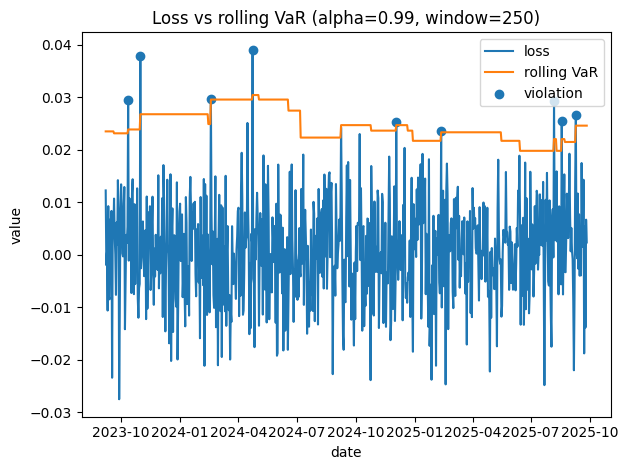

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(aligned.index, aligned["loss"], label="loss")
plt.plot(aligned.index, aligned["VaR"], label="rolling VaR")

v = aligned[aligned["violation"] == 1]
plt.scatter(v.index, v["loss"], marker="o", label="violation")

plt.title(f"Loss vs rolling VaR (alpha={alpha}, window={window})")
plt.xlabel("date")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.show()

## 6) Summary
- Ran rolling historical VaR backtesting on a long series (n>=250).
- Produced a compact report (n, x, observed vs expected rate, LR_POF, p-value).
- Visual check confirms violations occur when loss exceeds the rolling VaR threshold.


---

# Backtesting (real data): rolling VaR → violations → Kupiec POF + diagnostics

**Updated:** 2026-03-09  
**Goal:** Replace synthetic PnL with a real price/return series (SPY, >=250 obs), rerun backtest report + diagnostics, and save a report-ready plot.

## 1) Setup & imports 


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from riskmetrics.var import rolling_historical_var
from riskmetrics.backtest import var_violations, backtest_report

## 2) Load SPY price series (5y)

We use SPY daily adjusted prices (downloaded via `yfinance`) and saved as `data/price_SPY.csv` with columns: `date`, `price`.

In [25]:
df = pd.read_csv("../data/price_SPY.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

price = df["price"].astype(float)
df.head()

,price
date,
2021-03-08,356.326599
2021-03-09,361.414062
2021-03-10,363.663696
2021-03-11,367.350983
2021-03-12,367.845703


## 3) Convert price to log returns (PnL) and define loss

We treat daily log returns as PnL:
- $ \mathrm{PnL}_t = \log(P_t) - \log(P_{t-1}) $
- Loss convention: $ L_t = -\mathrm{PnL}_t $

In [26]:
pnl = np.log(price).diff().dropna()
loss = -pnl

pnl.head(), loss.head()

(date
 2021-03-09    0.014177
 2021-03-10    0.006205
 2021-03-11    0.010088
 2021-03-12    0.001346
 2021-03-15    0.005946
 Name: price, dtype: float64,
 date
 2021-03-09   -0.014177
 2021-03-10   -0.006205
 2021-03-11   -0.010088
 2021-03-12   -0.001346
 2021-03-15   -0.005946
 Name: price, dtype: float64)

## 4) Rolling historical VaR

We compute rolling historical VaR using:
- confidence level: alpha = 0.99
- rolling window: window = 250 (≈ 1 trading year)

Rolling VaR produces NaN for the first `window-1` points.

In [27]:
alpha = 0.99
window = 250

rvar = rolling_historical_var(pnl, window=window, alpha=alpha)
rvar.dropna().head()

date
2022-03-03    0.021535
2022-03-04    0.021535
2022-03-07    0.022084
2022-03-08    0.022084
2022-03-09    0.022084
Name: price, dtype: float64

## 5) Violations and Kupiec POF (coverage test)

Violation indicator:
- $ I_t = 1\{ L_t > \mathrm{VaR}_{\alpha,t} \} $

Kupiec POF tests whether the observed violation rate matches the expected rate $1-\alpha$.

In [28]:
viol = var_violations(loss, rvar)
rep = backtest_report(loss, rvar, alpha=alpha)
rep

{'n': 1006,
 'x': 19,
 'expected_rate': 0.010000000000000009,
 'observed_rate': 0.018886679920477135,
 'lr_pof': 6.363619565091511,
 'p_value': 0.011648368066473513}

## 6) Diagnostic table (alignment sanity check)

We align `loss` and `VaR` on the same date index and verify that violations occur exactly when `loss > VaR`.

In [29]:
aligned = pd.concat([loss.rename("loss"), rvar.rename("VaR")], axis=1).dropna()
aligned["violation"] = (aligned["loss"] > aligned["VaR"]).astype(int)
aligned.tail(10)

,loss,VaR,violation
date,,,
2026-02-23,0.010264,0.036278,0
2026-02-24,-0.007242,0.036278,0
2026-02-25,-0.008403,0.036278,0
2026-02-26,0.005570,0.036278,0
2026-02-27,0.004814,0.036278,0
2026-03-02,-0.000568,0.036278,0
2026-03-03,0.008853,0.036278,0
2026-03-04,-0.007031,0.036278,0
2026-03-05,0.005591,0.036278,0


## 7) Diagnostic plot (loss-only)

For readability, we plot only the positive part of loss (`loss_pos = max(loss, 0)`), together with rolling VaR.
Violation points are marked.

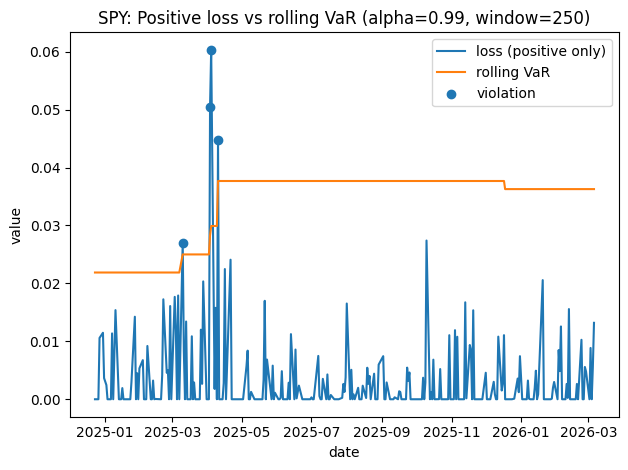

In [30]:
zoom_last = 300
aligned_zoom = aligned.tail(zoom_last)

aligned_zoom["loss_pos"] = aligned_zoom["loss"].clip(lower=0.0)
v = aligned_zoom[aligned_zoom["violation"] == 1]

plt.figure()
plt.plot(aligned_zoom.index, aligned_zoom["loss_pos"], label="loss (positive only)")
plt.plot(aligned_zoom.index, aligned_zoom["VaR"], label="rolling VaR")
plt.scatter(v.index, v["loss_pos"], marker="o", label="violation")

plt.title(f"SPY: Positive loss vs rolling VaR (alpha={alpha}, window={window})")
plt.xlabel("date")
plt.ylabel("value")
plt.legend()
plt.tight_layout()

out_path = "../data/spy_backtest_plot_loss_only.png"
plt.savefig(out_path, dpi=200)
out_path

plt.show()

## 8) Summary
- Using SPY 5-year daily prices, we computed log returns and rolling historical VaR (`alpha=0.99`, `window=250`).
- The compact backtest report includes (n, x, observed vs expected rate, LR_POF, p-value).
- The diagnostic plot confirms violations occur when loss exceeds the rolling VaR threshold.

---

# Coverage grid backtest (SPY): rolling Historical VaR + Kupiec POF

**Updated:** 2026-03-11  
**Goal:** Compare coverage across $(\alpha, \text{window})$ settings on real market data (SPY) and summarize how results change.

We test whether the observed VaR violation rate matches the expected rate:
- Expected violation rate: $p = 1-\alpha$
- Observed violation rate: $\hat p = x/n$

A Kupiec POF (Proportion of Failures) test checks whether $\hat p$ is statistically consistent with $p$.

## 1) Load SPY prices and build loss series

We use SPY daily prices (auto-adjusted) saved as `data/price_SPY.csv`.
We convert price to log returns and define loss as $L_t=-r_t$.

In [31]:
import numpy as np
import pandas as pd

from riskmetrics.var import rolling_historical_var
from riskmetrics.backtest import backtest_report

df = pd.read_csv("../data/price_SPY.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

price = df["price"].astype(float)

ret = np.log(price).diff()
loss = (-ret).dropna()

loss.head(), loss.shape

(date
 2021-03-09   -0.014177
 2021-03-10   -0.006205
 2021-03-11   -0.010088
 2021-03-12   -0.001346
 2021-03-15   -0.005946
 Name: price, dtype: float64,
 (1255,))

## 2) Run coverage grid (alpha × window)

Grid:
- $\alpha \in \{0.975, 0.99\}$
- window $\in \{125, 250, 500\}$

For each pair:
1) Compute rolling historical VaR from pnl/returns
2) Backtest against loss series
3) Summarize $(n, x, \hat p, p, \mathrm{LR}_{POF}, p\text{-value})$

In [32]:
alphas = [0.975, 0.99]
windows = [125, 250, 500]

rows = []

for alpha in alphas:
    for window in windows:
        pnl = -loss  # returns / pnl (profit positive)

        rvar = rolling_historical_var(pnl, window=window, alpha=alpha)

        rep = backtest_report(loss, rvar, alpha=alpha)

        rows.append(
            {
                "alpha": alpha,
                "window": window,
                "n": rep["n"],
                "x": rep["x"],
                "expected_rate": rep["expected_rate"],
                "observed_rate": rep["observed_rate"],
                "lr_pof": rep["lr_pof"],
                "p_value": rep["p_value"],
            }
        )

out = pd.DataFrame(rows).sort_values(["alpha", "window"]).reset_index(drop=True)
out

,alpha,window,n,x,expected_rate,observed_rate,lr_pof,p_value
0,0.975,125,1131,46,0.025,0.040672,9.609478,0.001936
1,0.975,250,1006,33,0.025,0.032803,2.291872,0.130053
2,0.975,500,756,19,0.025,0.025132,0.000542,0.981431
3,0.990,125,1131,24,0.010,0.021220,10.877962,0.000973
4,0.990,250,1006,19,0.010,0.018887,6.363620,0.011648
5,0.990,500,756,6,0.010,0.007937,0.349909,0.554165


## 3) How to interpret the table

- If `observed_rate > expected_rate` and p-value is small (e.g., < 0.05):
  - Too many violations → VaR is too small → under-coverage (risk underestimated)

- If `observed_rate < expected_rate` and p-value is small:
  - Too few violations → VaR is too large → over-coverage (risk overestimated)

- If p-value is large:
  - We fail to reject correct coverage (violations are consistent with expected rate)

## 4) Summary

- Short windows (125, 250) tend to under-cover at high confidence levels (especially 99%), producing more violations than expected.
- A longer window (500) stabilizes quantile estimation and yields coverage closer to the expected rate.
